In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
import json
import os

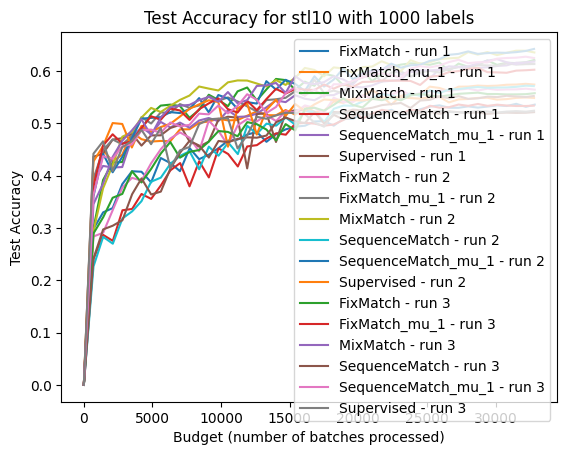

In [2]:
# Open results folder
results_parent_folder = "results/"
num_labeled = 1000
dataset = "stl10"
name_of_experiment = f"{dataset}_{num_labeled}_labels"
results_folder = os.path.join(results_parent_folder, name_of_experiment)
n_runs = 3
accs = {}
budgets = {}
for run in range(n_runs):
    path = results_folder + f"_run_{run+1}"
    if not os.path.exists(path):
        continue

    for file in os.listdir(path):
        method = file.split(".")[0]
        with open(os.path.join(path, file), "r") as f:
            data = json.load(f)
            accs[method] = accs.get(method, []) + [data["test_acc"]]
            budgets[method] = budgets.get(method, []) + [data["budget"]]
        # Plot the results
        plt.plot(data['budget'], data["test_acc"], label=f"{method} - run {run+1}")

# Add fully supervised baseline
for run in range(n_runs):
    path = f"results/{dataset}_full_sup_run_" + str(run+1)
    if not os.path.exists(path):
        continue
    with open(path+"/Full_Supervised.json", "r") as f:
        data = json.load(f)
        accs["Full_Supervised"] = accs.get("Full_Supervised", []) + [data["test_acc"]]
        budgets["Full_Supervised"] = budgets.get("Full_Supervised", []) + [data["budget"]]
    plt.plot(data['budget'], data["test_acc"], label=f"Full_Supervised - run {run+1}")

plt.xlabel("Budget (number of batches processed)")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy for {dataset} with {num_labeled} labels")
plt.legend()
plt.show()

In [3]:
# Print max accuracy and standard deviation for each method
for method, acc in accs.items():
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    # get max accuracy of each run
    max_acc = np.max(acc, axis=1)
    mean_max_acc = np.mean(max_acc)
    std_max_acc = np.std(max_acc)
    print(f"{method}: Max Test Accuracy = {mean_max_acc*100:.4f} ± {std_max_acc*100:.4f}")
    # print error rate   mean_error_rate = 1 - mean_max_acc
    mean_error_rate = 1 - mean_max_acc
    std_error_rate = std_max_acc
    print(f"{method}: Error Rate = {mean_error_rate*100:.4f} ± {std_error_rate*100:.4f}")
    print("\n")

FixMatch: Max Test Accuracy = 55.4292 ± 1.2275
FixMatch: Error Rate = 44.5708 ± 1.2275


FixMatch_mu_1: Max Test Accuracy = 59.9000 ± 1.6802
FixMatch_mu_1: Error Rate = 40.1000 ± 1.6802


MixMatch: Max Test Accuracy = 62.7792 ± 0.8037
MixMatch: Error Rate = 37.2208 ± 0.8037


SequenceMatch: Max Test Accuracy = 55.4125 ± 1.4316
SequenceMatch: Error Rate = 44.5875 ± 1.4316


SequenceMatch_mu_1: Max Test Accuracy = 62.8750 ± 1.0797
SequenceMatch_mu_1: Error Rate = 37.1250 ± 1.0797


Supervised: Max Test Accuracy = 53.3792 ± 1.1938
Supervised: Error Rate = 46.6208 ± 1.1938




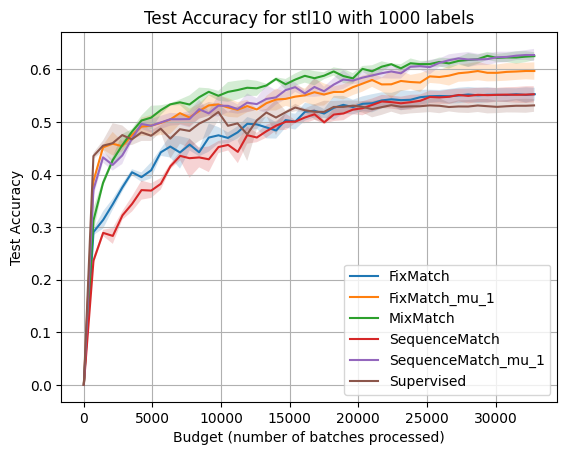

In [4]:
budgets_copy = budgets.copy()  # Create a copy to avoid modifying the original budgets
for method, acc in accs.items():
    # Handle the case where the acc has different lengths (e.g., due to missing runs)
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    budgets_copy[method] = budgets[method][0][:acc.shape[1]]  # Truncate budgets to match acc length
    # Compute mean and std
    mean_acc = np.mean(acc, axis=0)
    std_acc = np.std(acc, axis=0)
    # Plot the results
    plt.plot(budgets_copy[method], mean_acc, label=f"{method}")
    plt.fill_between(budgets_copy[method], mean_acc - std_acc, mean_acc + std_acc, alpha=0.2)
plt.xlabel("Budget (number of batches processed)")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy for {dataset} with {num_labeled} labels")
plt.legend()
plt.grid()
plt.show()

In [5]:
budget_per_iteration = {
    "Supervised": 1,
    "MixMatch": 3,
    "FixMatch": 15,
    "FixMatch_mu_1": 3,
    "SequenceMatch": 22,
    "SequenceMatch_mu_1": 4,
}

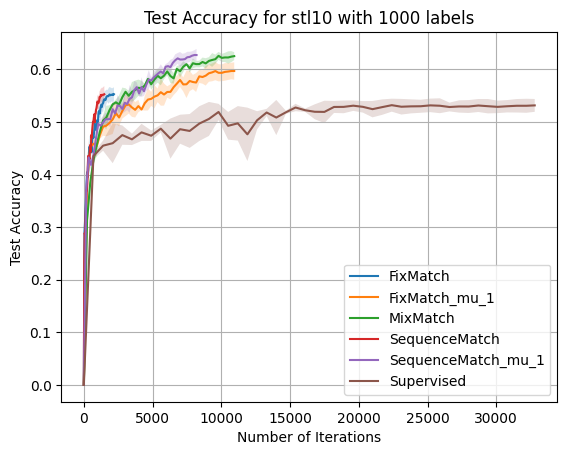

In [6]:
steps = {}
budgets_copy = budgets.copy()  # Create a copy to avoid modifying the original budgets
for method, acc in accs.items():
    # Handle the case where the acc has different lengths (e.g., due to missing runs)
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    steps[method] = np.array(budgets_copy[method][0][:acc.shape[1]]) / budget_per_iteration[method]  # Truncate budgets to match acc length
    # Compute mean and std
    mean_acc = np.mean(acc, axis=0)
    std_acc = np.std(acc, axis=0)
    # Plot the results
    plt.plot(steps[method], mean_acc, label=f"{method}")
    plt.fill_between(steps[method], mean_acc - std_acc, mean_acc + std_acc, alpha=0.2)
plt.xlabel("Number of Iterations")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy for {dataset} with {num_labeled} labels")
plt.legend()
plt.grid()
plt.show()